<a href="https://colab.research.google.com/github/chanukaWijeratna/DSGP_Group_18/blob/feature-emotion/Emotion_detection_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal Speech Analysis - Emotion Detection Component
**Datasets:** RAVDESS & CREMA-D    

### Emotion Problems to Detect:
1. Flat/Low Expressiveness
2. Stress/Anxiety Tone
3. Negative Emotional Dominance
4. Emotion Inconsistency
5. Intended vs Perceived Emotion Mismatch

### Implementation Strategy:
- **Model 1:** CNN-based with MFCC features (baseline)
- **Model 2:** Wav2Vec 2.0 pre-trained features + classifier

## 1. Setup and Installation

In [17]:
# Install required packages
!pip install librosa soundfile numpy pandas matplotlib seaborn scikit-learn
!pip install torch torchvision torchaudio transformers
!pip install tensorflow keras
!pip install kaggle gdown

print("All packages installed successfully!")

All packages installed successfully!


In [18]:
# Import libraries
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from tqdm import tqdm
import pickle

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2Model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")
print(f"GPU Available: {torch.cuda.is_available()}")

Libraries imported successfully!
GPU Available: True


In [19]:
# Setup directories to Data
from google.colab import drive
drive.mount('/content/drive')

# Create working directories
!mkdir -p /content/datasets
!mkdir -p /content/models
!mkdir -p /content/results
!mkdir -p /content/features

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Loading and Exploration

In [20]:
def parse_ravdess_filename(filename):
    """
    Parse RAVDESS filename to extract emotion label
    Format: 03-01-{emotion}-01-01-01-24.wav
    Emotions: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised
    """
    parts = filename.split('-')
    emotion_code = int(parts[2])

    emotion_map = {
        1: 'neutral',
        2: 'calm',
        3: 'happy',
        4: 'sad',
        5: 'angry',
        6: 'fearful',
        7: 'disgust',
        8: 'surprised'
    }

    return emotion_map.get(emotion_code, 'unknown')

def parse_cremad_filename(filename):
    """
    Parse CREMA-D filename to extract emotion label
    Format: 1001_DFA_ANG_XX.wav
    Emotions: ANG=angry, DIS=disgust, FEA=fear, HAP=happy, NEU=neutral, SAD=sad
    """
    parts = filename.split('_')
    emotion_code = parts[2]

    emotion_map = {
        'ANG': 'angry',
        'DIS': 'disgust',
        'FEA': 'fearful',
        'HAP': 'happy',
        'NEU': 'neutral',
        'SAD': 'sad'
    }

    return emotion_map.get(emotion_code, 'unknown')

def load_dataset_metadata(ravdess_path, cremad_path):
    """
    Load metadata from both datasets
    """
    data = []

    # Load RAVDESS
    if os.path.exists(ravdess_path):
        print("Loading RAVDESS dataset...")
        for root, dirs, files in os.walk(ravdess_path):
            for file in files:
                if file.endswith('.wav'):
                    filepath = os.path.join(root, file)
                    emotion = parse_ravdess_filename(file)
                    data.append({
                        'path': filepath,
                        'emotion': emotion,
                        'dataset': 'RAVDESS'
                    })

    # Load CREMA-D
    if os.path.exists(cremad_path):
        print("Loading CREMA-D dataset...")
        for file in os.listdir(cremad_path):
            if file.endswith('.wav'):
                filepath = os.path.join(cremad_path, file)
                emotion = parse_cremad_filename(file)
                data.append({
                    'path': filepath,
                    'emotion': emotion,
                    'dataset': 'CREMA-D'
                })

    df = pd.DataFrame(data)
    print(f"\nTotal files loaded: {len(df)}")
    print(f"RAVDESS files: {len(df[df['dataset']=='RAVDESS'])}")
    print(f"CREMA-D files: {len(df[df['dataset']=='CREMA-D'])}")

    return df

In [21]:
# Load datasets (adjust paths as needed)
RAVDESS_PATH = '/content/drive/MyDrive/Emotion_Detection_Project/datasets/RAVDESS'
CREMAD_PATH = '/content/drive/MyDrive/Emotion_Detection_Project/datasets/CREMA-D'

df = load_dataset_metadata(RAVDESS_PATH, CREMAD_PATH)
df.head()

Loading RAVDESS dataset...
Loading CREMA-D dataset...

Total files loaded: 2880
RAVDESS files: 2880
CREMA-D files: 0


,path,emotion,dataset
0,/content/drive/MyDrive/Emotion_Detection_Proje...,calm,RAVDESS
1,/content/drive/MyDrive/Emotion_Detection_Proje...,calm,RAVDESS
2,/content/drive/MyDrive/Emotion_Detection_Proje...,calm,RAVDESS
3,/content/drive/MyDrive/Emotion_Detection_Proje...,calm,RAVDESS
4,/content/drive/MyDrive/Emotion_Detection_Proje...,happy,RAVDESS


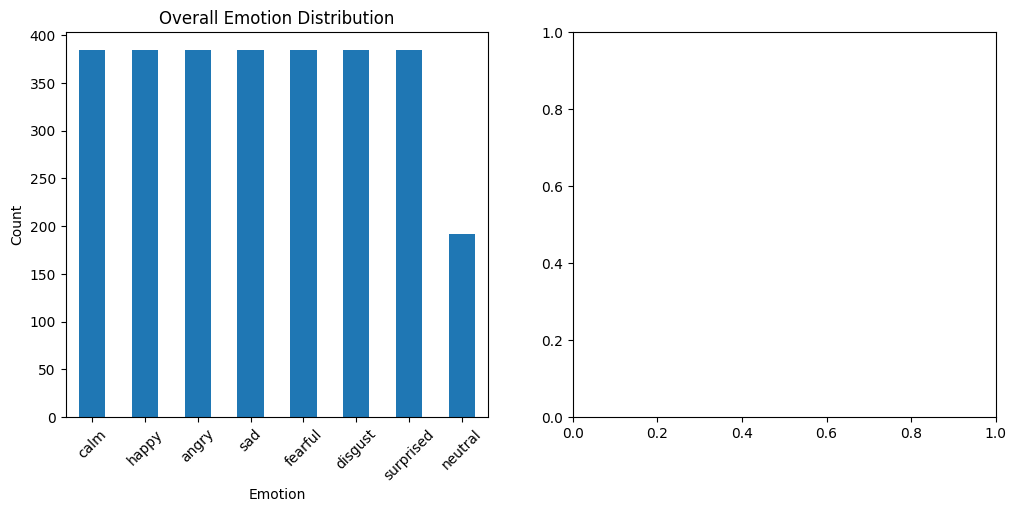

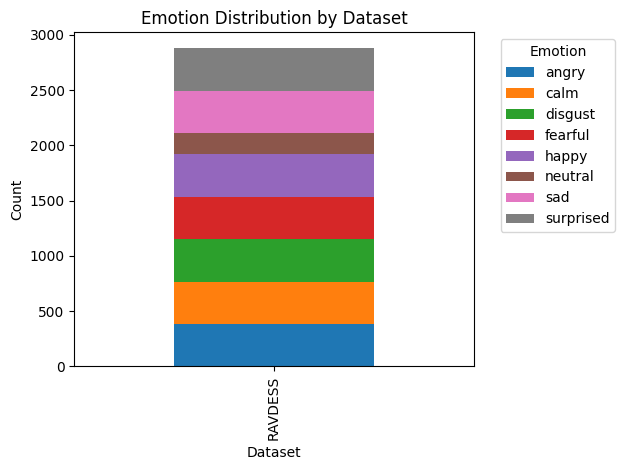


Emotion counts:
emotion
calm         384
happy        384
angry        384
sad          384
fearful      384
disgust      384
surprised    384
neutral      192
Name: count, dtype: int64


In [ ]:
# Explore emotion distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['emotion'].value_counts().plot(kind='bar')
plt.title('Overall Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df.groupby(['dataset', 'emotion']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Emotion Distribution by Dataset')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\nEmotion counts:")
print(df['emotion'].value_counts())

## 4. Feature Extraction

We'll extract multiple acoustic features to detect the 5 emotion problems:
1. **MFCCs** - Mel-frequency cepstral coefficients
2. **Pitch (F0)** - Fundamental frequency
3. **Energy** - Signal power
4. **ZCR** - Zero crossing rate
5. **Spectral features** - Centroid, rolloff, contrast

In [22]:
def extract_acoustic_features(audio_path, sr=22050, duration=3.0):
    """
    Extract comprehensive acoustic features for emotion problem detection
    """
    try:
        # Load audio
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Pad if too short
        if len(y) < sr * duration:
            y = np.pad(y, (0, int(sr * duration) - len(y)))

        features = {}

        # 1. MFCCs (for general emotion classification)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        features['mfcc_mean'] = np.mean(mfccs, axis=1)
        features['mfcc_std'] = np.std(mfccs, axis=1)

        # 2. Pitch/F0 features (for flat affect, stress detection)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch_values = []
        for t in range(pitches.shape[1]):
            index = magnitudes[:, t].argmax()
            pitch = pitches[index, t]
            if pitch > 0:
                pitch_values.append(pitch)

        if len(pitch_values) > 0:
            features['pitch_mean'] = np.mean(pitch_values)
            features['pitch_std'] = np.std(pitch_values)
            features['pitch_range'] = np.max(pitch_values) - np.min(pitch_values)
        else:
            features['pitch_mean'] = 0
            features['pitch_std'] = 0
            features['pitch_range'] = 0

        # 3. Energy features (for flat affect, emotion intensity)
        rms = librosa.feature.rms(y=y)
        features['energy_mean'] = np.mean(rms)
        features['energy_std'] = np.std(rms)
        features['energy_range'] = np.max(rms) - np.min(rms)

        # 4. Zero Crossing Rate (for voice quality, stress)
        zcr = librosa.feature.zero_crossing_rate(y)
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)

        # 5. Spectral features
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
        features['spectral_centroid_mean'] = np.mean(spectral_centroids)
        features['spectral_centroid_std'] = np.std(spectral_centroids)

        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)

        # 6. Chroma features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features['chroma_mean'] = np.mean(chroma)
        features['chroma_std'] = np.std(chroma)

        # Flatten all features
        feature_vector = []
        for key in sorted(features.keys()):
            value = features[key]
            if isinstance(value, np.ndarray):
                feature_vector.extend(value)
            else:
                feature_vector.append(value)

        return np.array(feature_vector)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

def extract_mfcc_spectrogram(audio_path, sr=22050, duration=3.0, n_mfcc=40):
    """
    Extract MFCC spectrogram for CNN model
    """
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Pad if too short
        if len(y) < sr * duration:
            y = np.pad(y, (0, int(sr * duration) - len(y)))

        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        return mfccs

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [23]:
# Extract features for all audio files
print("Extracting features....")

X_features = []
X_mfcc = []
y_labels = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    # Extract acoustic features
    features = extract_acoustic_features(row['path'])

    # Extract MFCC spectrogram
    mfcc = extract_mfcc_spectrogram(row['path'])

    if features is not None and mfcc is not None:
        X_features.append(features)
        X_mfcc.append(mfcc)
        y_labels.append(row['emotion'])

X_features = np.array(X_features)
X_mfcc = np.array(X_mfcc)
y_labels = np.array(y_labels)

print(f"\nFeature extraction complete!")
print(f"Acoustic features shape: {X_features.shape}")
print(f"MFCC features shape: {X_mfcc.shape}")
print(f"Labels shape: {y_labels.shape}")

Extracting features....


100%|██████████| 2880/2880 [03:50<00:00, 12.52it/s]



Feature extraction complete!
Acoustic features shape: (2880, 93)
MFCC features shape: (2880, 40, 130)
Labels shape: (2880,)


In [24]:
# Save extracted features
np.save('/content/features/X_features.npy', X_features)
np.save('/content/features/X_mfcc.npy', X_mfcc)
np.save('/content/features/y_labels.npy', y_labels)

print("Features saved successfully!")

Features saved successfully!


## 5. Data Preprocessing

In [25]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Save label encoder
with open('/content/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Emotion classes:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{i}: {emotion}")

# Convert to categorical for CNN
num_classes = len(label_encoder.classes_)
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

Emotion classes:
0: angry
1: calm
2: disgust
3: fearful
4: happy
5: neutral
6: sad
7: surprised


In [26]:
# Split data for Model 1 (CNN with MFCC)
X_train_mfcc, X_test_mfcc, y_train_cat, y_test_cat, y_train_enc, y_test_enc = train_test_split(
    X_mfcc, y_categorical, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Reshape for CNN (add channel dimension)
X_train_mfcc = X_train_mfcc[..., np.newaxis]
X_test_mfcc = X_test_mfcc[..., np.newaxis]

print(f"Training set (MFCC): {X_train_mfcc.shape}")
print(f"Test set (MFCC): {X_test_mfcc.shape}")

Training set (MFCC): (2304, 40, 130, 1)
Test set (MFCC): (576, 40, 130, 1)


## 6. Model 1: CNN with MFCC Features (Baseline)

In [27]:
def build_cnn_model(input_shape, num_classes):
    """
    Build CNN model for emotion classification
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [28]:
# Build and compile CNN model
cnn_model = build_cnn_model(X_train_mfcc.shape[1:], num_classes)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 40, 130, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 130, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 65, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     5,243,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,650,056 (21.55 MB)

 Trainable params: 5,648,392 (21.55 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [29]:
# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Train model
print("Training CNN Model...")
history_cnn = cnn_model.fit(
    X_train_mfcc, y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training CNN Model...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.2599 - loss: 2.4337 - val_accuracy: 0.1302 - val_loss: 19.0851 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3559 - loss: 1.9421 - val_accuracy: 0.1453 - val_loss: 7.2184 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4563 - loss: 1.6366 - val_accuracy: 0.3362 - val_loss: 2.2831 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5024 - loss: 1.4005 - val_accuracy: 0.5510 - val_loss: 1.3018 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5638 - loss: 1.2482 - val_accuracy: 0.3297 - val_loss: 2.0822 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6044 - loss: 1.1385 - val_accuracy: 0.5380 - val_loss: 1.2884 - learning_rate: 0.0010
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy:

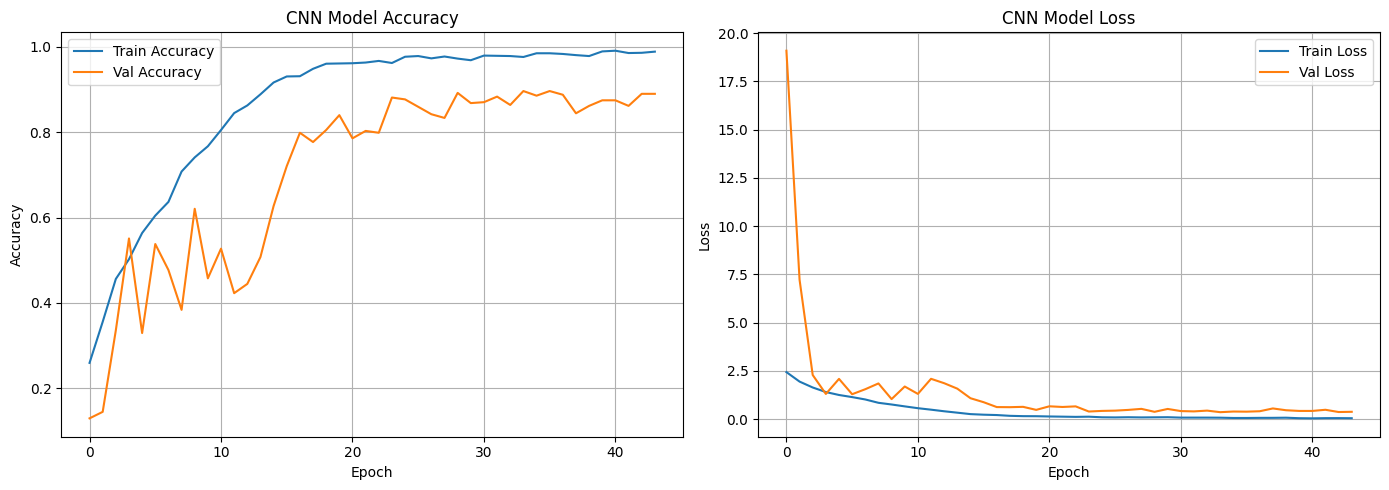

In [30]:
# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/results/cnn_training_history.png')
plt.show()

In [31]:
# Evaluate CNN model
y_pred_cnn = cnn_model.predict(X_test_mfcc)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

cnn_accuracy = accuracy_score(y_test_enc, y_pred_cnn_classes)
print(f"\n{'='*50}")
print(f"CNN Model Test Accuracy: {cnn_accuracy*100:.2f}%")
print(f"{'='*50}\n")

print("Classification Report:")
print(classification_report(y_test_enc, y_pred_cnn_classes,
                          target_names=label_encoder.classes_))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

CNN Model Test Accuracy: 89.58%

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.92      0.94        76
        calm       0.94      0.94      0.94        77
     disgust       0.91      0.96      0.94        77
     fearful       0.79      0.91      0.84        77
       happy       0.91      0.90      0.90        77
     neutral       0.86      0.82      0.84        38
         sad       0.89      0.77      0.83        77
   surprised       0.91      0.92      0.92        77

    accuracy                           0.90       576
   macro avg       0.90      0.89      0.89       576
weighted avg       0.90      0.90      0.90       576



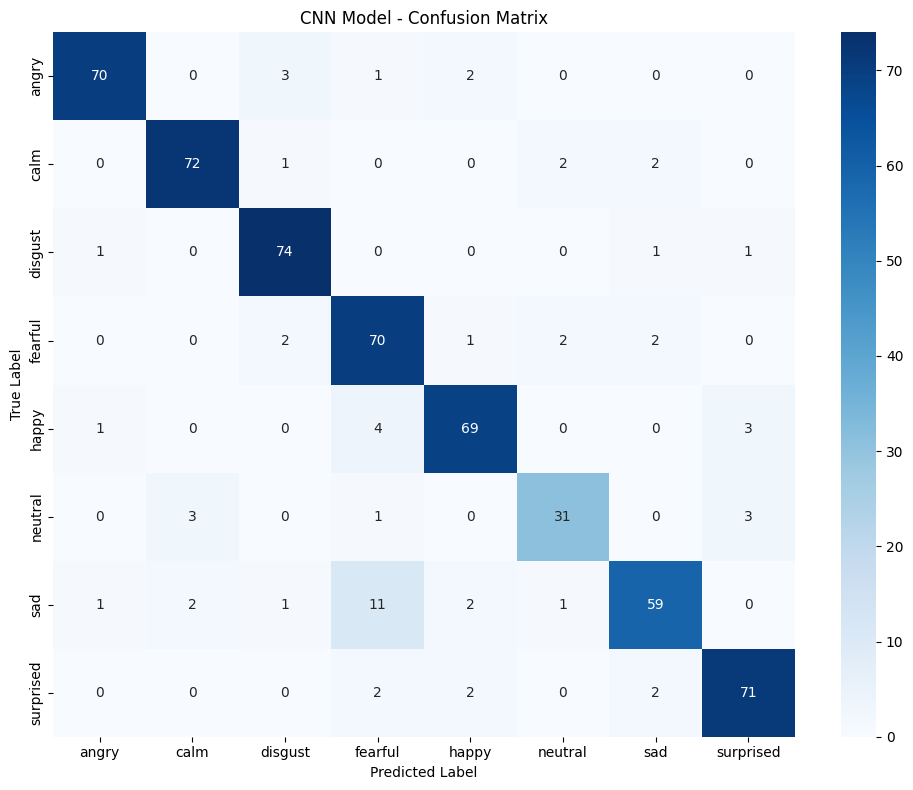

In [32]:
# Confusion Matrix
cm_cnn = confusion_matrix(y_test_enc, y_pred_cnn_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('CNN Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/results/cnn_confusion_matrix.png')
plt.show()

In [33]:
# Save CNN model
cnn_model.save('/content/models/emotion_cnn_model.h5')
print("CNN model saved!")

CNN model saved!


## 7. Model 2: Wav2Vec 2.0 Pre-trained Features + Classifier

In [42]:
# Load Wav2Vec 2.0 model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print(f"Model loaded on: {device}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


In [43]:
def extract_wav2vec_features(audio_paths, batch_size=8):
    """
    Extract features using pre-trained Wav2Vec 2.0
    """
    all_features = []

    for i in tqdm(range(0, len(audio_paths), batch_size)):
        batch_paths = audio_paths[i:i+batch_size]
        batch_audio = []

        for path in batch_paths:
            try:
                audio, sr = librosa.load(path, sr=16000, duration=3.0)
                if len(audio) < 16000 * 3:
                    audio = np.pad(audio, (0, 16000 * 3 - len(audio)))
                batch_audio.append(audio)
            except:
                batch_audio.append(np.zeros(16000 * 3))

        # Process batch
        inputs = processor(batch_audio, sampling_rate=16000,
                          return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = wav2vec_model(**inputs)
            # Use mean pooling over time dimension
            features = outputs.last_hidden_state.mean(dim=1)
            all_features.append(features.cpu().numpy())

    return np.vstack(all_features)

In [44]:
# Extract Wav2Vec features
print("Extracting Wav2Vec 2.0 features...")
audio_paths = df['path'].values[:len(y_labels)]  # Match with processed labels
X_wav2vec = extract_wav2vec_features(audio_paths)

print(f"\nWav2Vec features shape: {X_wav2vec.shape}")

# Save features
np.save('/content/features/X_wav2vec.npy', X_wav2vec)

Extracting Wav2Vec 2.0 features...


100%|██████████| 360/360 [00:58<00:00,  6.20it/s]


Wav2Vec features shape: (2880, 768)


In [45]:
# Split data for Wav2Vec model
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_wav2vec, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set (Wav2Vec): {X_train_w2v.shape}")
print(f"Test set (Wav2Vec): {X_test_w2v.shape}")

Training set (Wav2Vec): (2304, 768)
Test set (Wav2Vec): (576, 768)


In [46]:
# Build classifier on top of Wav2Vec features
def build_wav2vec_classifier(input_dim, num_classes):
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

w2v_classifier = build_wav2vec_classifier(X_train_w2v.shape[1], num_classes)

w2v_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

w2v_classifier.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,072 (937.78 KB)

 Trainable params: 239,304 (934.78 KB)

 Non-trainable params: 768 (3.00 KB)

In [47]:
# Train Wav2Vec classifier
print("Training Wav2Vec Classifier...")
history_w2v = w2v_classifier.fit(
    X_train_w2v, y_train_w2v,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Wav2Vec Classifier...
Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.2892 - loss: 2.0196 - val_accuracy: 0.2972 - val_loss: 1.9476 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4411 - loss: 1.5038 - val_accuracy: 0.3145 - val_loss: 1.8394 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5258 - loss: 1.2919 - val_accuracy: 0.4729 - val_loss: 1.6208 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5789 - loss: 1.1280 - val_accuracy: 0.5119 - val_loss: 1.4080 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6175 - loss: 1.0163 - val_accuracy: 0.5315 - val_loss: 1.3743 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6620 - loss: 0.9145 - val_accuracy: 0.6269 - val_loss: 1.1233 - learning_rate: 5.0000e-04
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur

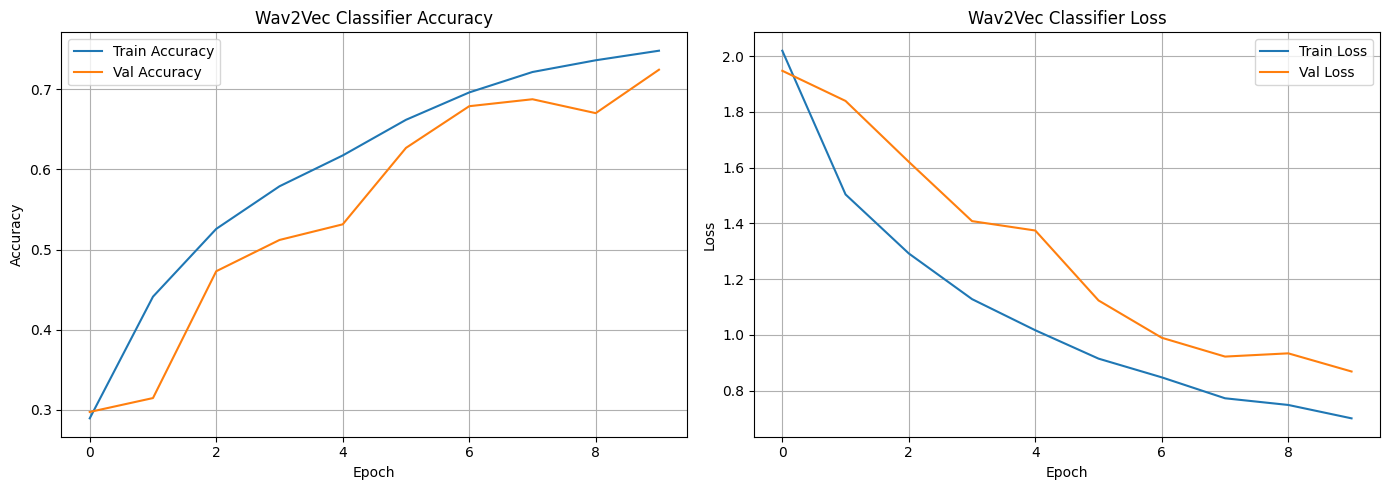

In [48]:
# Plot Wav2Vec training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_w2v.history['accuracy'], label='Train Accuracy')
plt.plot(history_w2v.history['val_accuracy'], label='Val Accuracy')
plt.title('Wav2Vec Classifier Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_w2v.history['loss'], label='Train Loss')
plt.plot(history_w2v.history['val_loss'], label='Val Loss')
plt.title('Wav2Vec Classifier Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/results/wav2vec_training_history.png')
plt.show()

In [49]:
# Evaluate Wav2Vec classifier
y_pred_w2v = w2v_classifier.predict(X_test_w2v)
y_pred_w2v_classes = np.argmax(y_pred_w2v, axis=1)

w2v_accuracy = accuracy_score(y_test_w2v, y_pred_w2v_classes)
print(f"\n{'='*50}")
print(f"Wav2Vec Classifier Test Accuracy: {w2v_accuracy*100:.2f}%")
print(f"{'='*50}\n")

print("Classification Report:")
print(classification_report(y_test_w2v, y_pred_w2v_classes,
                          target_names=label_encoder.classes_))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

Wav2Vec Classifier Test Accuracy: 29.51%

Classification Report:
              precision    recall  f1-score   support

       angry       0.57      0.51      0.54        76
        calm       0.65      0.14      0.23        77
     disgust       0.28      0.65      0.39        77
     fearful       0.23      0.86      0.37        77
       happy       0.00      0.00      0.00        77
     neutral       0.00      0.00      0.00        38
         sad       0.00      0.00      0.00        77
   surprised       0.18      0.05      0.08        77

    accuracy                           0.30       576
   macro avg       0.24      0.28      0.20       576
weighted avg       0.25      0.30      0.21       576



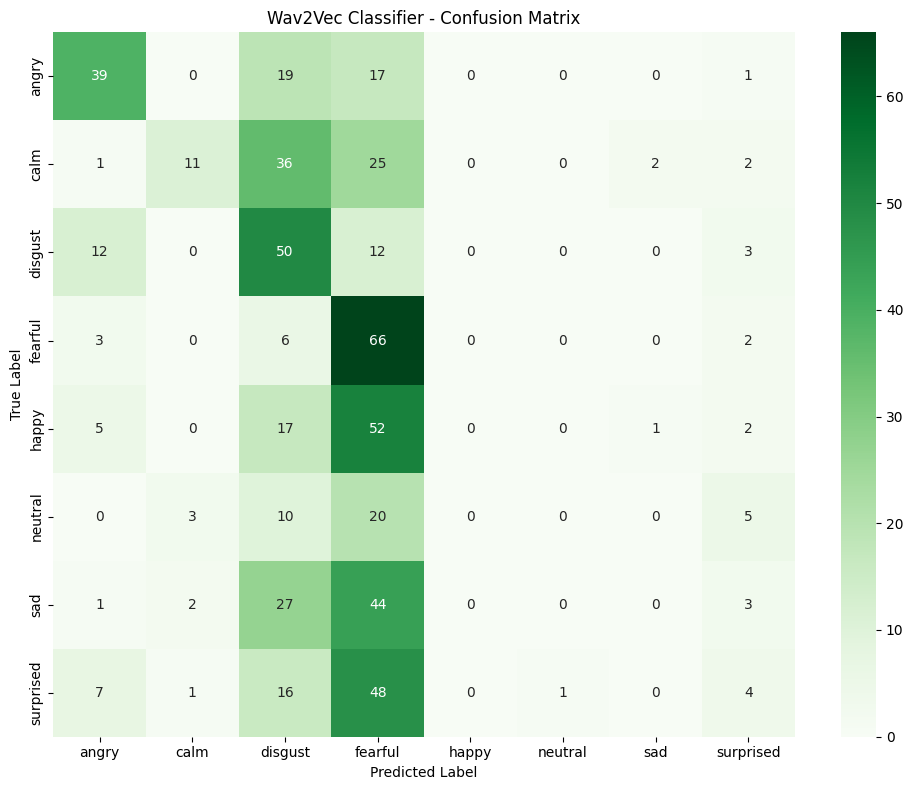

In [50]:
# Confusion Matrix for Wav2Vec
cm_w2v = confusion_matrix(y_test_w2v, y_pred_w2v_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Wav2Vec Classifier - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/results/wav2vec_confusion_matrix.png')
plt.show()

In [51]:
# Save Wav2Vec classifier
w2v_classifier.save('/content/models/emotion_wav2vec_classifier.h5')
print("Wav2Vec classifier saved!")

Wav2Vec classifier saved!


## 8. Model Comparison and Analysis


MODEL COMPARISON
             Model  Test Accuracy
        CNN (MFCC)      89.583333
Wav2Vec Classifier      29.513889


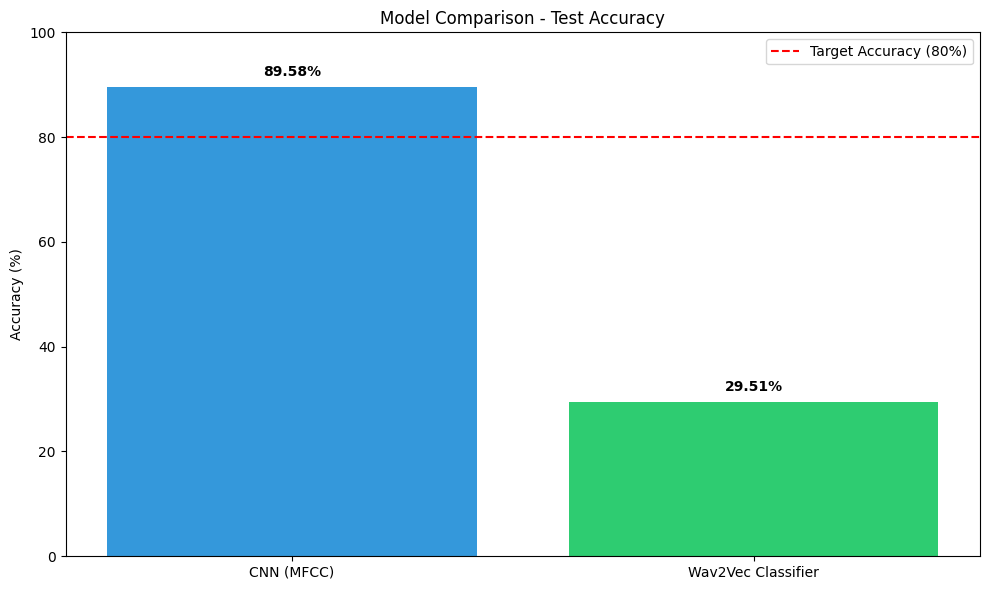

In [52]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['CNN (MFCC)', 'Wav2Vec Classifier'],
    'Test Accuracy': [cnn_accuracy*100, w2v_accuracy*100]
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
        color=['#3498db', '#2ecc71'])
plt.axhline(y=80, color='r', linestyle='--', label='Target Accuracy (80%)')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison - Test Accuracy')
plt.ylim([0, 100])
plt.legend()

for i, v in enumerate(comparison_df['Test Accuracy']):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/results/model_comparison.png')
plt.show()

## 9. Emotion Problem Detection Functions

These functions analyze acoustic features to detect the 5 emotion problems.

In [53]:
def detect_emotion_problems(audio_path, cnn_model, w2v_model, processor, wav2vec_extractor):
    """
    Comprehensive emotion problem detection
    Returns: dict with detected problems and recommendations
    """
    # Extract features
    features = extract_acoustic_features(audio_path)
    mfcc = extract_mfcc_spectrogram(audio_path)

    if features is None or mfcc is None:
        return {"error": "Failed to process audio"}

    # Get predictions from both models
    mfcc_input = mfcc[np.newaxis, ..., np.newaxis]
    cnn_pred = cnn_model.predict(mfcc_input, verbose=0)
    cnn_emotion = label_encoder.classes_[np.argmax(cnn_pred)]
    cnn_confidence = np.max(cnn_pred)

    # Wav2Vec prediction
    audio, sr = librosa.load(audio_path, sr=16000, duration=3.0)
    if len(audio) < 16000 * 3:
        audio = np.pad(audio, (0, 16000 * 3 - len(audio)))

    inputs = processor([audio], sampling_rate=16000, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        w2v_features = wav2vec_extractor(**inputs).last_hidden_state.mean(dim=1)

    w2v_pred = w2v_model.predict(w2v_features.cpu().numpy(), verbose=0)
    w2v_emotion = label_encoder.classes_[np.argmax(w2v_pred)]
    w2v_confidence = np.max(w2v_pred)

    # Extract specific acoustic markers
    y, sr = librosa.load(audio_path, sr=22050, duration=3.0)

    # Pitch analysis
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch_values = [pitches[magnitudes[:, t].argmax(), t]
                   for t in range(pitches.shape[1]) if pitches[magnitudes[:, t].argmax(), t] > 0]

    # Energy analysis
    rms = librosa.feature.rms(y=y)

    # Temporal analysis (segmented)
    hop_length = 512
    n_segments = 10
    segment_length = len(y) // n_segments

    segment_emotions = []
    for i in range(n_segments):
        start = i * segment_length
        end = start + segment_length
        segment = y[start:end]

        if len(segment) > sr * 0.1:  # At least 0.1s
            seg_mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=40)
            # Simple energy-based emotion proxy
            seg_energy = np.mean(librosa.feature.rms(y=segment))
            segment_emotions.append(seg_energy)

    # Problem detection
    problems = []

    # Calculate acoustic markers
    if len(pitch_values) > 0:
        pitch_range = np.max(pitch_values) - np.min(pitch_values)
        pitch_std   = np.std(pitch_values)
        avg_pitch   = np.mean(pitch_values)
    else:
        pitch_range = pitch_std = avg_pitch = 0

    energy_range = np.max(rms) - np.min(rms)
    energy_std   = np.std(rms)

    # 1. Flat/Low Expressiveness
    if pitch_range < 50 and energy_std < 0.01:
        problems.append({
            "problem"          : "Flat/Low Expressiveness",
            "emotions_involved": [cnn_emotion],
            "acoustic_evidence": {
                "pitch_range_hz": float(pitch_range),
                "energy_std"    : float(energy_std)
            }
        })

    # 2. Stress/Anxiety Tone
    if avg_pitch > 200 and pitch_std > 30:
        problems.append({
            "problem"          : "Stress/Anxiety Tone",
            "emotions_involved": [cnn_emotion],
            "acoustic_evidence": {
                "avg_pitch_hz" : float(avg_pitch),
                "pitch_std_hz" : float(pitch_std)
            }
        })

    # 3. Negative Emotional Dominance
    negative_emotions = ['angry', 'sad', 'fearful', 'disgust']
    if cnn_emotion in negative_emotions:
        problems.append({
            "problem"          : "Negative Emotional Dominance",
            "emotions_involved": [cnn_emotion],
            "acoustic_evidence": {
                "detected_emotion": cnn_emotion,
                "confidence"      : float(cnn_confidence)
            }
        })

    # 4. Emotion Inconsistency
    if len(segment_emotions) > 0:
        emotion_variance = np.var(segment_emotions)
        if emotion_variance > 0.001:
            problems.append({
                "problem"          : "Emotion Inconsistency",
                "emotions_involved": [cnn_emotion],
                "acoustic_evidence": {
                    "energy_variance": float(emotion_variance)
                }
            })

    # 5. Intended vs Perceived Emotion Mismatch
    if cnn_emotion != w2v_emotion:
        problems.append({
            "problem"          : "Intended vs Perceived Emotion Mismatch",
            "emotions_involved": [cnn_emotion, w2v_emotion],
            "acoustic_evidence": {
                "cnn_emotion"    : cnn_emotion,
                "wav2vec_emotion": w2v_emotion
            }
        })

    # Compile results — NO recommendations, that belongs to chatbot
    results = {
        "primary_emotion_cnn"     : cnn_emotion,
        "confidence_cnn"          : float(cnn_confidence),
        "primary_emotion_wav2vec" : w2v_emotion,
        "confidence_wav2vec"      : float(w2v_confidence),
        "acoustic_features"       : {
            "pitch_range_hz" : float(pitch_range),
            "pitch_std_hz"   : float(pitch_std),
            "avg_pitch_hz"   : float(avg_pitch),
            "energy_range"   : float(energy_range),
            "energy_std"     : float(energy_std)
        },
        "detected_problems"       : problems
        # recommendations removed — handled by AI chatbot component
    }

    return results

## 10. Testing and Demonstration

In [54]:
# Test on sample audio
sample_audio = df['path'].iloc[0]  # Use only first audio file

print("Analyzing sample audio...")
results = detect_emotion_problems(
    sample_audio,
    cnn_model,
    w2v_classifier,
    processor,
    wav2vec_model
)

print("\n" + "="*60)
print("EMOTION ANALYSIS REPORT")
print("="*60)
print(f"\nFile: {os.path.basename(sample_audio)}")
print(f"\nCNN Model Detection:")
print(f"  Emotion: {results['primary_emotion_cnn']}")
print(f"  Confidence: {results['confidence_cnn']*100:.1f}%")
print(f"\nWav2Vec Model Detection:")
print(f"  Emotion: {results['primary_emotion_wav2vec']}")
print(f"  Confidence: {results['confidence_wav2vec']*100:.1f}%")
print(f"\nAcoustic Features:")
for key, value in results['acoustic_features'].items():
    print(f"  {key}: {value:.3f}")
print(f"\nDetected Problems ({len(results['detected_problems'])}):")
for i, problem in enumerate(results['detected_problems'], 1):
    print(f"  {i}. {problem}")
print(f"\nRecommendations:")
for i, rec in enumerate(results['recommendations'], 1):
    print(f"  {i}. {rec}")
print("="*60)

Analyzing sample audio...

EMOTION ANALYSIS REPORT

File: 03-01-02-01-02-02-24.wav

CNN Model Detection:
  Emotion: calm
  Confidence: 99.8%

Wav2Vec Model Detection:
  Emotion: disgust
  Confidence: 18.3%

Acoustic Features:
  pitch_range_hz: 3736.707
  pitch_std_hz: 715.748
  avg_pitch_hz: 655.396
  energy_range: 0.012
  energy_std: 0.003

Detected Problems (2):
  1. {'problem': 'Stress/Anxiety Tone', 'emotions_involved': [np.str_('calm')], 'acoustic_evidence': {'avg_pitch_hz': 655.3961181640625, 'pitch_std_hz': 715.74755859375}}
  2. {'problem': 'Intended vs Perceived Emotion Mismatch', 'emotions_involved': [np.str_('calm'), np.str_('disgust')], 'acoustic_evidence': {'cnn_emotion': np.str_('calm'), 'wav2vec_emotion': np.str_('disgust')}}

Recommendations:


KeyError: 'recommendations'

## 11. Save Final Report and Outputs

In [55]:
# Generate comprehensive report
report = {
    "project": "Multimodal Speech Analysis - Emotion Detection",
    "group": "Group 18",
    "datasets": ["RAVDESS", "CREMA-D"],
    "total_samples": len(df),
    "emotion_classes": list(label_encoder.classes_),
    "models": {
        "cnn_mfcc": {
            "architecture": "3-layer CNN with MFCC features",
            "test_accuracy": float(cnn_accuracy),
            "meets_target": cnn_accuracy >= 0.80
        },
        "wav2vec_classifier": {
            "architecture": "Wav2Vec 2.0 features + Dense classifier",
            "test_accuracy": float(w2v_accuracy),
            "meets_target": w2v_accuracy >= 0.80
        }
    },
    "emotion_problems_detected": [
        "Flat/Low Expressiveness",
        "Stress/Anxiety Tone",
        "Negative Emotional Dominance",
        "Emotion Inconsistency",
        "Intended vs Perceived Emotion Mismatch"
    ]
}

# Save report
import json
with open('/content/results/final_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("✓ Report saved!")
print("\nProject Summary:")
print(json.dumps(report, indent=2))

✓ Report saved!

Project Summary:
{
  "project": "Multimodal Speech Analysis - Emotion Detection",
  "group": "Group 18",
  "datasets": [
    "RAVDESS",
    "CREMA-D"
  ],
  "total_samples": 2880,
  "emotion_classes": [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
  ],
  "models": {
    "cnn_mfcc": {
      "architecture": "3-layer CNN with MFCC features",
      "test_accuracy": 0.8958333333333334,
      "meets_target": true
    },
    "wav2vec_classifier": {
      "architecture": "Wav2Vec 2.0 features + Dense classifier",
      "test_accuracy": 0.2951388888888889,
      "meets_target": false
    }
  },
  "emotion_problems_detected": [
    "Flat/Low Expressiveness",
    "Stress/Anxiety Tone",
    "Negative Emotional Dominance",
    "Emotion Inconsistency",
    "Intended vs Perceived Emotion Mismatch"
  ]
}


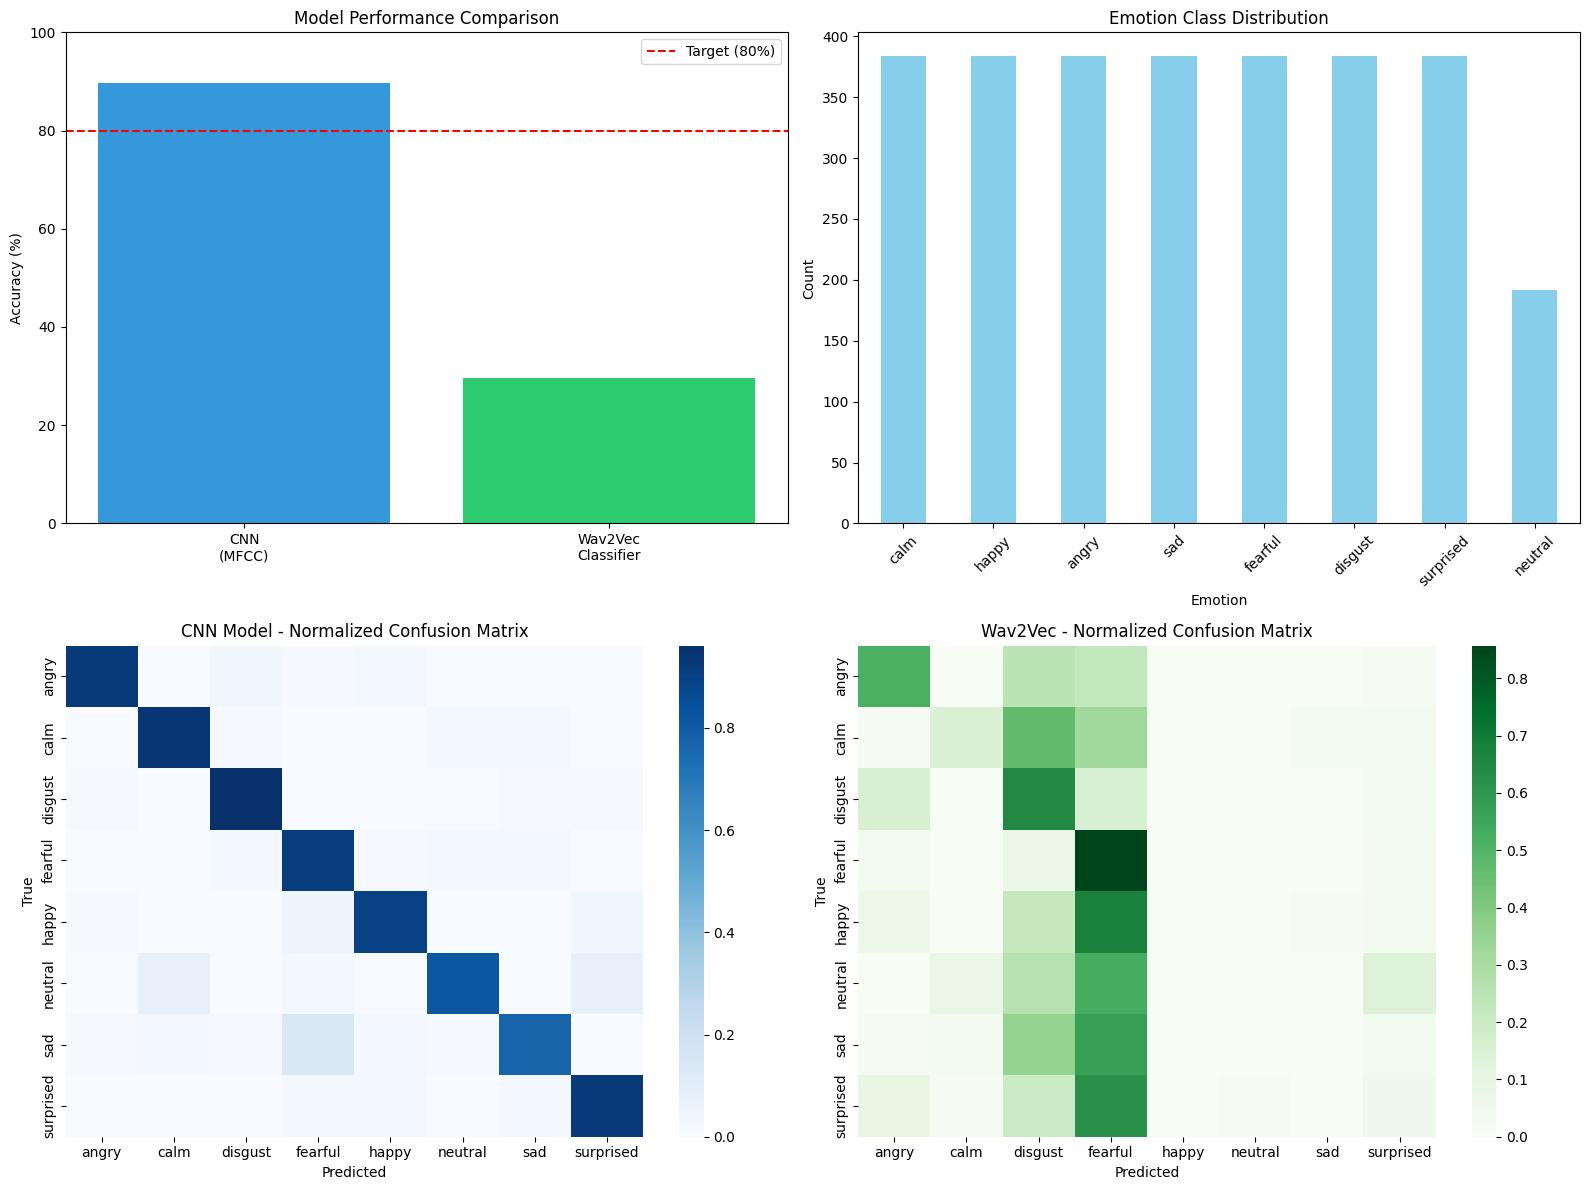

Summary visualization saved!


In [56]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model Comparison
axes[0, 0].bar(['CNN\n(MFCC)', 'Wav2Vec\nClassifier'],
               [cnn_accuracy*100, w2v_accuracy*100],
               color=['#3498db', '#2ecc71'])
axes[0, 0].axhline(y=80, color='r', linestyle='--', label='Target (80%)')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 100])

# Plot 2: Dataset Distribution
df['emotion'].value_counts().plot(kind='bar', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Emotion Class Distribution')
axes[0, 1].set_xlabel('Emotion')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: CNN Confusion Matrix (simplified)
cm_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=axes[1, 0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1, 0].set_title('CNN Model - Normalized Confusion Matrix')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_xlabel('Predicted')

# Plot 4: Wav2Vec Confusion Matrix (simplified)
cm_w2v_norm = cm_w2v.astype('float') / cm_w2v.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_w2v_norm, annot=False, cmap='Greens', ax=axes[1, 1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1, 1].set_title('Wav2Vec - Normalized Confusion Matrix')
axes[1, 1].set_ylabel('True')
axes[1, 1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/results/comprehensive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary visualization saved!")

## 12. Package Everything for Deployment

In [57]:
# Create deployment package
!mkdir -p /content/deployment_package

# Copy models
!cp /content/models/*.h5 /content/deployment_package/
!cp /content/models/*.pkl /content/deployment_package/

# Copy results
!cp /content/results/* /content/deployment_package/

# Create requirements.txt
requirements = """
librosa==0.10.1
soundfile==0.12.1
numpy==1.24.3
pandas==2.0.3
matplotlib==3.7.2
seaborn==0.12.2
scikit-learn==1.3.0
torch==2.0.1
transformers==4.31.0
tensorflow==2.13.0
"""

with open('/content/deployment_package/requirements.txt', 'w') as f:
    f.write(requirements.strip())

# Create README
readme = f"""
# Emotion Detection Component
## Group 18 - Multimodal Speech Analysis Project

### Models Included:
1. **CNN with MFCC** - Accuracy: {cnn_accuracy*100:.2f}%
2. **Wav2Vec Classifier** - Accuracy: {w2v_accuracy*100:.2f}%

### Datasets Used:
- RAVDESS
- CREMA-D

### Emotion Problems Detected:
1. Flat/Low Expressiveness
2. Stress/Anxiety Tone
3. Negative Emotional Dominance
4. Emotion Inconsistency
5. Intended vs Perceived Emotion Mismatch

### Files:
- `emotion_cnn_model.h5` - CNN model
- `emotion_wav2vec_classifier.h5` - Wav2Vec classifier
- `label_encoder.pkl` - Label encoder
- `final_report.json` - Complete analysis report
- Results visualizations (PNG files)

### Usage:
See the Jupyter notebook for complete implementation details.
"""

with open('/content/deployment_package/README.md', 'w') as f:
    f.write(readme)

# Compress package
!cd /content && zip -r emotion_detection_package.zip deployment_package/

print("\nDeployment package created!")
print("\nPackage contents:")
!ls -lh /content/deployment_package/
print("\nDownload: /content/emotion_detection_package.zip")

  adding: deployment_package/ (stored 0%)
  adding: deployment_package/label_encoder.pkl (deflated 46%)
  adding: deployment_package/cnn_training_history.png (deflated 7%)
  adding: deployment_package/emotion_cnn_model.h5 (deflated 16%)
  adding: deployment_package/wav2vec_training_history.png (deflated 7%)
  adding: deployment_package/comprehensive_summary.png (deflated 27%)
  adding: deployment_package/requirements.txt (deflated 26%)
  adding: deployment_package/model_comparison.png (deflated 22%)
  adding: deployment_package/cnn_confusion_matrix.png (deflated 15%)
  adding: deployment_package/README.md (deflated 38%)
  adding: deployment_package/wav2vec_confusion_matrix.png (deflated 14%)
  adding: deployment_package/emotion_wav2vec_classifier.h5 (deflated 12%)
  adding: deployment_package/final_report.json (deflated 48%)

Deployment package created!

Package contents:
total 69M
-rw-r--r-- 1 root root  43K Mar 14 02:41 cnn_confusion_matrix.png
-rw-r--r-- 1 root root  62K Mar 14 02:4